# Generate images in 512x512

In [1]:
# from models.fmri_encoder import FMRI2CLIP
from models.fmri_c2f_encoder import FMRI2CLIP

/data1/zx/switti-right/models/basic_switti.py:25: UserWarning: Cannot import apex RMSNorm, switch to vanilla implementation
  warnings.warn("Cannot import apex RMSNorm, switch to vanilla implementation")


In [2]:
subj = 2
if subj == 1:
    num_voxels = 15724
elif subj == 2:
    num_voxels = 14278
elif subj == 3:
    num_voxels = 15226
elif subj == 4:
    num_voxels = 13153
elif subj == 5:
    num_voxels = 13039
elif subj == 6:
    num_voxels = 17907
elif subj == 7:
    num_voxels = 12682
elif subj == 8:
    num_voxels = 14386

In [3]:
import torch
from models.helpers import DropPath
from models import Switti, VQVAE
from models.pipeline_recs_persample import SwittiPipeline
device = 'cuda:1'
pn = "1_2_3_4_6_9_13_18_24_32"
patch_nums = tuple(map(int, pn.replace("-", "_").split("_")))
switti = Switti(
            depth=30,
            embed_dim=30 * 64,
            num_heads=30,
            drop_rate=0,
            attn_drop_rate=0,
            drop_path_rate=0,
            norm_eps=1e-6,
            attn_l2_norm=True,
            patch_nums=patch_nums,
            rope=True,
            rope_theta=10000,
            rope_size=128,
            use_swiglu_ffn=True,
            use_ar=False,
            use_crop_cond=False,
        ).to(device)
vae_local = VQVAE(
    vocab_size=4096,
    z_channels=32,
    ch=160,
    test_mode=True,
    share_quant_resi=4,
    v_patch_nums=patch_nums,
).to(device)
# fmri_encoder = FMRI2CLIP().to(device)



# fmri_vitl = FMRI2CLIP(input_dim=num_voxels,
#                         d_model=768,
#                         fmri_seq_len=100,
#                         image_seq_len=257,
#                         text_seq_len=77,
#                         num_layers=10).to(device)

fmri_vitl = FMRI2CLIP(input_dim=num_voxels,
                    d_model=768,#768,
                    fmri_seq_len=100,
                    image_seq_len=257,
                    text_seq_len=77,
                    num_layers=4).to(device)

pipe = SwittiPipeline(switti, vae_local, fmri_vitl, device)


[constructor]  ==== fused_if_available=True (fusing_add_ln=0/30, fusing_mlp=0/30) ==== 
    [Switti config ] embed_dim=1920, num_heads=30, depth=30, mlp_ratio=4.0
    [drop ratios ] drop_rate=0, attn_drop_rate=0, drop_path_rate=0 (tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0.]))



In [4]:
def count_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print('param counts:\n{:,} total\n{:,} trainable'.format(total, trainable))
    
count_params(pipe.switti) 
count_params(pipe.vae) 
count_params(fmri_vitl)

param counts:
2,318,294,656 total
2,318,294,656 trainable
param counts:
108,948,355 total
0 trainable
param counts:
301,369,344 total
301,369,344 trainable


In [5]:
switti_path = f"local_output/subj{subj}_lr5e-7_1e-4_cos_vitL_hierachy_12to24_rightway/model_state_dict.pt"
# switti_path = f"local_output/subj{subj}_lr5e-7_8e-5_cos_vitL_hierachy_12and24_rightway/model_state_dict.pt"
pipe.pretrained(switti_path, subj=subj, device=device, torch_dtype=torch.bfloat16, reso=512)

/data1/zx/switti-right/models/pipeline_recs_persample.py:52: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(fmri_vitl_ckpt, map_location='cpu')


In [6]:
import webdataset as wds
import h5py
import numpy as np

In [7]:
voxels = {}
# Load hdf5 data for betas
f = h5py.File(f'dataset/mindeyev2/betas_all_subj0{subj}_fp32_renorm.hdf5', 'r')
betas = f['betas'][:]
betas = torch.Tensor(betas).to("cpu")
num_voxels = betas[0].shape[-1]
voxels[f'subj0{subj}'] = betas
print(f"num_voxels for subj0{subj}: {num_voxels}")

num_voxels for subj02: 14278


In [8]:

if subj==3:
    num_test=2371
elif subj==4:
    num_test=2188
elif subj==6:
    num_test=2371
elif subj==8:
    num_test=2188
else: 
    num_test=3000
test_url = f"dataset/mindeyev2/wds/subj0{subj}/new_test/" + "0.tar"

In [9]:
test_data = wds.WebDataset(test_url,resampled=False,nodesplitter=lambda urls: urls)\
                    .decode("torch")\
                    .rename(behav="behav.npy", past_behav="past_behav.npy", future_behav="future_behav.npy", olds_behav="olds_behav.npy")\
                    .to_tuple(*["behav", "past_behav", "future_behav", "olds_behav"])
test_dl = torch.utils.data.DataLoader(test_data, batch_size=num_test, shuffle=False, drop_last=True, pin_memory=True)

/home/zhangx/miniconda3/envs/switti/lib/python3.11/site-packages/webdataset/compat.py:389: UserWarning: WebDataset(shardshuffle=...) is None; set explicitly to False or a number
  warnings.warn(


In [10]:
test_images_idx = []
test_voxels_idx = []
for test_i, (behav, past_behav, future_behav, old_behav) in enumerate(test_dl):
    test_voxels = voxels[f'subj0{subj}'][behav[:,0,5].cpu().long()]
    test_voxels_idx = np.append(test_voxels_idx, behav[:,0,5].cpu().numpy())
    test_images_idx = np.append(test_images_idx, behav[:,0,0].cpu().numpy())
test_images_idx = test_images_idx.astype(int)
test_voxels_idx = test_voxels_idx.astype(int)

assert (test_i+1) * num_test == len(test_voxels) == len(test_images_idx)
print(test_i, len(test_voxels), len(test_images_idx), len(np.unique(test_images_idx)))

0 3000 3000 1000


In [11]:
all_images = torch.load(f"pretrained/all_images.pt")

/tmp/ipykernel_958849/1306615227.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  all_images = torch.load(f"pretrained/all_images.pt")


In [12]:
from mindbridge_models import Clipper
clip_extractor = Clipper("ViT-L/14", hidden_state=False, norm_embs=True, device=device)

In [13]:
import numpy as np
import torch
import time

# --- Setup ---
# Assume pipe, test_voxels, test_images_idx, and device are already defined.
sub_voxel_batch_size = 1
# --- Timed Execution Block ---
# Synchronize CUDA to get an accurate start time
torch.cuda.synchronize()
start_time = time.time()

# --- Step 1: Prepare and Average Input Voxels ---
# This step is part of the total time as it prepares the specific input tensor.
unique_indices = np.unique(test_images_idx)
averaged_voxels_list = []
for uniq_img in unique_indices:
    locs = np.where(test_images_idx == uniq_img)[0]
    if len(locs) == 1:
        locs = locs.repeat(3)
    elif len(locs) == 2:
        locs = locs.repeat(2)[:3]
    
    averaged_voxel = torch.mean(test_voxels[locs], dim=0, keepdim=True)
    averaged_voxels_list.append(averaged_voxel)

input_voxels_tensor = torch.cat(averaged_voxels_list, dim=0)

# --- Step 2: Run Batched Inference ---
all_recons_list = []
with torch.no_grad(), torch.amp.autocast('cuda', dtype=torch.float32):
    # Removed tqdm from the loop for clean timing
    for i in range(0, len(input_voxels_tensor), sub_voxel_batch_size):
        # if i not in [24, 32, 42, 70, 80, 90]:
        #     continue
        batch_voxels = input_voxels_tensor[i:i + sub_voxel_batch_size].to(device)
        batch_samples = pipe(prompt=batch_voxels, 
                             cfg=6,
                             top_k=400,
                             top_p=0.95,
                             recons_per_sample=4,
                             return_pil=False,
                             turn_on_cfg_start_si=1,
                             original_image=all_images[i].unsqueeze(0),
                             clip_extractor=clip_extractor,
                             seed=59,
                             verbose_timing=False)
        
        all_recons_list.append(batch_samples.cpu())
        
        # Explicitly delete tensors and clear cache
        del batch_voxels
        del batch_samples
        torch.cuda.empty_cache()

# --- Step 3: Finalize Results ---
final_recons = torch.cat(all_recons_list, dim=0)

# Synchronize CUDA to ensure all GPU tasks are finished before stopping the timer
torch.cuda.synchronize()
end_time = time.time()
# --- End of Timed Block ---


# --- Report Results ---
execution_time = end_time - start_time
print(f"✅ Time to produce all_recons: {execution_time:.2f} seconds")

# #---------------------------------------------------------------------------

# # import torch
# # final_recons = torch.load('subj2_tmp_all_recons.pt')

all_recons = final_recons
# # # all_recons.shape
torch.save(all_recons, f'subj{subj}_tmp_all_recons_4sample.pt')
# print(f"Final output shape: {final_recons.shape}")

/data1/zx/switti-right/models/rope.py:43: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):


✅ Time to produce all_recons: 2698.90 seconds


In [14]:
# subj = 2
# final_recons = torch.load(f'subj{subj}_tmp_all_recons.pt')

In [15]:
from torchvision import transforms
imsize = 256
if final_recons.shape[-1] != imsize:
    final_recons = transforms.Resize((imsize,imsize))(final_recons).float()
blury_recons = torch.load(f'/data1/zx/Brain_model_for_test/new_test/MindEyeV2/src/evals/final_subj0{subj}_pretrained_40sess_24bs/final_subj0{subj}_pretrained_40sess_24bs_all_blurryrecons.pt')
alpha = 1 - 0.45
final_recons = alpha*final_recons + (1-alpha)*blury_recons

/tmp/ipykernel_958849/2268790276.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  blury_recons = torch.load(f'/data1/zx/Brain_model_for_test/new_test/MindEyeV2/src/evals/

In [16]:
# #--------------------
# # CODE OPTIMIZED FOR MEMORY
# #--------------------
# from tqdm import tqdm
# import numpy as np
# import torch

# # This is the size of the batches we feed to the GPU.
# # Adjust based on your GPU memory (VRAM). A power of 2 is common.
# sub_voxel_batch_size = 10 # You may still need to lower this!

# # --- Step 1: Prepare ALL sub-voxels (same as before) ---
# print("Preparing all sub-voxels...")
# unique_indices = np.unique(test_images_idx)
# num_unique_images = len(unique_indices)

# all_sub_voxels_list = []
# for uniq_img in tqdm(unique_indices):
#     locs = np.where(test_images_idx == uniq_img)[0]
#     if len(locs) == 1:
#         locs = locs.repeat(3)
#     elif len(locs) == 2:
#         locs = locs.repeat(2)[:3]
#     assert len(locs) == 3
#     all_sub_voxels_list.append(test_voxels[locs])

# # --- Step 2: Create the tensor on the CPU, NOT the GPU ---
# all_sub_voxels_tensor = torch.cat(all_sub_voxels_list, dim=0) 
# print(f"Total sub-voxels to process: {len(all_sub_voxels_tensor)}")

# # --- Step 1 & 2: Prepare and Average Input Voxels ---
# print("Averaging sub-voxels before inference...")
# unique_indices = np.unique(test_images_idx)
# num_unique_images = len(unique_indices)

# averaged_voxels_list = []
# for uniq_img in tqdm(unique_indices):
#     locs = np.where(test_images_idx == uniq_img)[0]
#     if len(locs) == 1:
#         locs = locs.repeat(3)
#     elif len(locs) == 2:
#         locs = locs.repeat(2)[:3]
#     assert len(locs) == 3
    
#     # Average the 3 sub-voxels for the current image and add to the list
#     averaged_voxel = torch.mean(test_voxels[locs], dim=0, keepdim=True)
#     averaged_voxels_list.append(averaged_voxel)

# # Create the input tensor from the list of averaged voxels
# input_voxels_tensor = torch.cat(averaged_voxels_list, dim=0) 
# print(f"Total averaged voxels to process: {len(input_voxels_tensor)}")

# # --- Step 3: Run inference in batches on all sub-voxels ---
# all_recons_list = []
# print("Running batched inference on all sub-voxels...")
# with torch.no_grad(), torch.amp.autocast('cuda', dtype=torch.float32):
#     for i in tqdm(range(0, len(input_voxels_tensor), sub_voxel_batch_size)):
#         batch_voxels = input_voxels_tensor[i:i + sub_voxel_batch_size].to(device)

#         # Call the pipe on the batch of sub-voxels.
#         batch_samples = pipe(prompt=batch_voxels, 
#                              cfg=6,
#                              top_k=400,
#                              top_p=0.95,
#                              return_pil=False,
#                              turn_on_cfg_start_si=1,
#                              seed=59)
        
#         # Move the results immediately to the CPU to free up VRAM.
#         all_recons_list.append(batch_samples.cpu())

#         # MEMORY FIX 3: Explicitly delete tensors and clear cache.
#         # This can help in very tight memory situations.
#         del batch_voxels
#         del batch_samples
#         torch.cuda.empty_cache()

# # --- Step 4: Finalize Results ---
# print("Concatenating final results...")
# # The outputs are already the final reconstructions. Just concatenate the batches.
# final_recons = torch.cat(all_recons_list, dim=0)

# print(f"Final output shape: {final_recons.shape}")

In [17]:
# import torch
# import os
# from PIL import Image
# from torchvision import transforms

# # --- Configuration ---
# # 1. Directory where your images are stored.
# IMAGE_DIR = "dataset/images/"

# # 2. List of integer indices for the images you want to process.
# IMAGE_INDICES = unique_indices

# # 3. Path for the output file.
# OUTPUT_FILE = "all_images.pt"

# # --- Script ---
# # This list will hold each converted image tensor.
# tensor_list = []

# # This defines the conversion from a PIL Image to a PyTorch Tensor.
# # It now includes resizing the image to 512x512 pixels.
# transform = transforms.Compose([
#     transforms.Resize((512, 512)),
#     transforms.ToTensor(),
# ])


# print(f"Starting image processing...")

# # Loop through each integer index provided.
# for idx in IMAGE_INDICES:
#     # Format the integer index into a 6-digit string (e.g., 1 -> "000001").
#     # Then, construct the full filename.
#     filename = f"image_{idx:06d}.png"
#     filepath = os.path.join(IMAGE_DIR, filename)

#     # Try to open the image and process it.
#     try:
#         # Open the image file and convert it to RGB format.
#         image = Image.open(filepath).convert("RGB")
        
#         # Apply the transform to resize and convert the image to a tensor.
#         image_tensor = transform(image)
        
#         # Add the tensor to our list.
#         tensor_list.append(image_tensor)
#         print(f"Successfully processed: {filename}")
        
#     except FileNotFoundError:
#         print(f"⚠️  Warning: Could not find {filename}. Skipping.")
#     except Exception as e:
#         print(f"❌ Error processing {filename}: {e}")

# # Check if any images were successfully processed.
# if tensor_list:
#     # Stack all individual tensors into a single tensor.
#     all_images_tensor = torch.stack(tensor_list)

#     # Save the final tensor to the specified file.
#     torch.save(all_images_tensor, OUTPUT_FILE)

#     print("\n✅ Done!")
#     print(f"Tensor with {len(tensor_list)} images saved to '{OUTPUT_FILE}'")
#     print(f"Final Tensor Shape: {all_images_tensor.shape}")
# else:
#     print("\n❌ No images were processed.")


In [18]:
# ground truths
all_images = torch.load(f"pretrained/all_images.pt")


/tmp/ipykernel_958849/4117169610.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  all_images = torch.load(f"pretrained/all_images.pt")


In [19]:
all_recons = final_recons

In [20]:
from torchvision import transforms

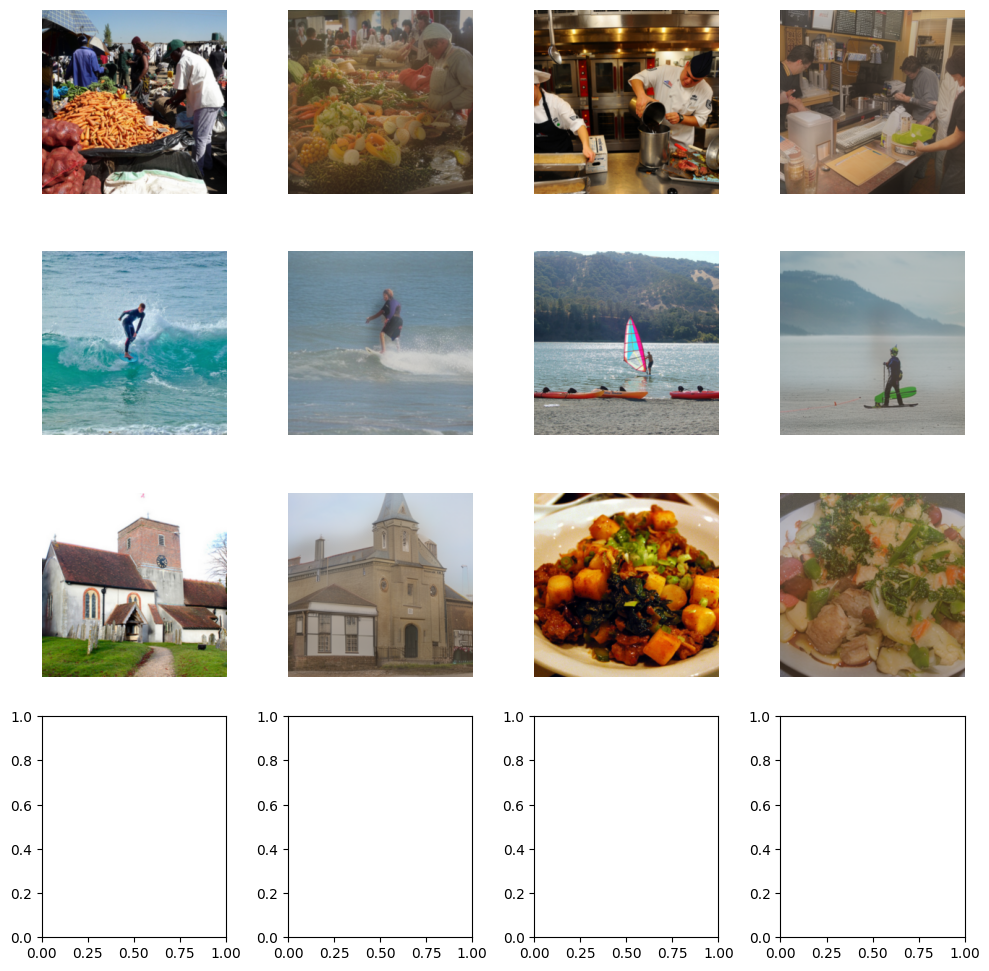

In [21]:
import matplotlib.pyplot as plt
imsize = 256
if all_images.shape[-1] != imsize:
    all_images = transforms.Resize((imsize,imsize))(all_images).float()
if all_recons.shape[-1] != imsize:
    all_recons = transforms.Resize((imsize,imsize))(all_recons).float()
    
def torch_to_Image(x):
    if x.ndim==4:
        x=x[0]
    return transforms.ToPILImage()(x)

# MODIFIED: Changed grid from (3, 4) to (4, 4) and adjusted figsize
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
jj=-1; kk=0
# MODIFIED: Added 2 more indices to the array to provide 8 pairs for the 4x4 grid
# base = 8*67
# image_indices = np.array(list(range(base, base+8)))
image_indices = [0, 1, 2, 3, 4, 5]#[234, 210, 183, 155, 126, 90, 208, 215] #v3 541, 289, 395, 403, 462, 487, 509, 510 # v1   222, 241, 246, 263, 271, 321, 365, 375
for j in image_indices:
    jj+=1
    axes[kk][jj].imshow(torch_to_Image(all_images[j]))
    axes[kk][jj].axis('off')
    
    jj+=1
    axes[kk][jj].imshow(torch_to_Image(all_recons[j]))
    axes[kk][jj].axis('off')
    
    if jj==3: 
        kk+=1; jj=-1
        
plt.tight_layout()
plt.show()

## 2-way identification

In [22]:

from torchvision.models.feature_extraction import create_feature_extractor

@torch.no_grad()
def two_way_identification(all_recons, all_images, model, preprocess, feature_layer=None, return_avg=True):
    preds = model(torch.stack([preprocess(recon) for recon in all_recons], dim=0).to(device))
    reals = model(torch.stack([preprocess(indiv) for indiv in all_images], dim=0).to(device))
    if feature_layer is None:
        preds = preds.float().flatten(1).cpu().numpy()
        reals = reals.float().flatten(1).cpu().numpy()
    else:
        preds = preds[feature_layer].float().flatten(1).cpu().numpy()
        reals = reals[feature_layer].float().flatten(1).cpu().numpy()

    r = np.corrcoef(reals, preds)
    r = r[:len(all_images), len(all_images):]
    congruents = np.diag(r)

    success = r < congruents
    success_cnt = np.sum(success, 0)

    if return_avg:
        perf = np.mean(success_cnt) / (len(all_images)-1)
        return perf
    else:
        return success_cnt, len(all_images)-1

## PixCorr

In [23]:
from tqdm import tqdm
import numpy as np
import torch
preprocess = transforms.Compose([
    transforms.Resize(425, interpolation=transforms.InterpolationMode.BILINEAR),
])

# Flatten images while keeping the batch dimension
all_images_flattened = preprocess(all_images).reshape(len(all_images), -1).cpu()
all_recons_flattened = preprocess(all_recons).view(len(all_recons), -1).cpu()

print(all_images_flattened.shape)
print(all_recons_flattened.shape)

corrsum = 0
for i in tqdm(range(len(all_images))):
    corrsum += np.corrcoef(all_images_flattened[i], all_recons_flattened[i])[0][1]
corrmean = corrsum / len(all_images)

pixcorr = corrmean
print(pixcorr)


torch.Size([1000, 541875])
torch.Size([1000, 541875])


100%|██████████| 1000/1000 [00:05<00:00, 186.75it/s]

0.33325045500199796


## SSIM

In [24]:
# see https://github.com/zijin-gu/meshconv-decoding/issues/3
from skimage.color import rgb2gray
from skimage.metrics import structural_similarity as ssim

preprocess = transforms.Compose([
    transforms.Resize(425, interpolation=transforms.InterpolationMode.BILINEAR), 
])

# convert image to grayscale with rgb2grey
img_gray = rgb2gray(preprocess(all_images).permute((0,2,3,1)).cpu())
recon_gray = rgb2gray(preprocess(all_recons).permute((0,2,3,1)).cpu())
print("converted, now calculating ssim...")

ssim_score=[]
for im,rec in tqdm(zip(img_gray,recon_gray),total=len(all_images)):
    ssim_score.append(ssim(rec, im, multichannel=True, gaussian_weights=True, sigma=1.5, use_sample_covariance=False, data_range=1.0))

ssim = np.mean(ssim_score)
print(ssim)

converted, now calculating ssim...


100%|██████████| 1000/1000 [00:15<00:00, 66.27it/s]

0.4617317940735103


## AlexNet

In [25]:

device = 'cuda:2'
from torchvision.models import alexnet, AlexNet_Weights
alex_weights = AlexNet_Weights.IMAGENET1K_V1

alex_model = create_feature_extractor(alexnet(weights=alex_weights), return_nodes=['features.4','features.11']).to(device)
alex_model.eval().requires_grad_(False)

# see alex_weights.transforms()
preprocess = transforms.Compose([
    transforms.Resize(256, interpolation=transforms.InterpolationMode.BILINEAR),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

layer = 'early, AlexNet(2)'
print(f"\n---{layer}---")
all_per_correct = two_way_identification(all_recons.to(device).float(), all_images, 
                                                          alex_model, preprocess, 'features.4')
alexnet2 = np.mean(all_per_correct)
print(f"2-way Percent Correct: {alexnet2:.4f}")

layer = 'mid, AlexNet(5)'
print(f"\n---{layer}---")
all_per_correct = two_way_identification(all_recons.to(device).float(), all_images, 
                                                          alex_model, preprocess, 'features.11')
alexnet5 = np.mean(all_per_correct)
print(f"2-way Percent Correct: {alexnet5:.4f}")


---early, AlexNet(2)---
2-way Percent Correct: 0.9427

---mid, AlexNet(5)---
2-way Percent Correct: 0.9845


## InceptionV3

In [26]:
from torchvision.models import inception_v3, Inception_V3_Weights
weights = Inception_V3_Weights.DEFAULT
inception_model = create_feature_extractor(inception_v3(weights=weights), 
                                           return_nodes=['avgpool']).to(device)
inception_model.eval().requires_grad_(False)

# see weights.transforms()
preprocess = transforms.Compose([
    transforms.Resize(342, interpolation=transforms.InterpolationMode.BILINEAR),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

with torch.amp.autocast('cuda', dtype=torch.float32):
    all_per_correct = two_way_identification(all_recons, all_images,
                                            inception_model, preprocess, 'avgpool')
        
inception = np.mean(all_per_correct)
print(f"2-way Percent Correct: {inception:.4f}")


/home/zhangx/miniconda3/envs/switti/lib/python3.11/site-packages/torchvision/models/feature_extraction.py:174: UserWarning: NOTE: The nodes obtained by tracing the model in eval mode are a subsequence of those obtained in train mode. When choosing nodes for feature extraction, you may need to specify output nodes for train and eval mode separately.
  warnings.warn(msg + suggestion_msg)


2-way Percent Correct: 0.9622


## CLIP

In [27]:
import clip
clip_model, preprocess = clip.load("ViT-L/14", device=device)

preprocess = transforms.Compose([
    transforms.Resize(224, interpolation=transforms.InterpolationMode.BILINEAR),
    transforms.Normalize(mean=[0.48145466, 0.4578275, 0.40821073],
                         std=[0.26862954, 0.26130258, 0.27577711]),
])

all_per_correct = two_way_identification(all_recons, all_images,
                                        clip_model.encode_image, preprocess, None) # final layer
clip_ = np.mean(all_per_correct)
print(f"2-way Percent Correct: {clip_:.4f}")


2-way Percent Correct: 0.9478


## Efficient Net

In [28]:
import scipy as sp
from torchvision.models import efficientnet_b1, EfficientNet_B1_Weights
weights = EfficientNet_B1_Weights.DEFAULT
eff_model = create_feature_extractor(efficientnet_b1(weights=weights), 
                                    return_nodes=['avgpool'])
eff_model.eval().requires_grad_(False)

# see weights.transforms()
preprocess = transforms.Compose([
    transforms.Resize(255, interpolation=transforms.InterpolationMode.BILINEAR),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

gt = eff_model(preprocess(all_images))['avgpool']
gt = gt.reshape(len(gt),-1).cpu().numpy()
fake = eff_model(preprocess(all_recons.float() ))['avgpool']
fake = fake.reshape(len(fake),-1).cpu().numpy()

effnet = np.array([sp.spatial.distance.correlation(gt[i],fake[i]) for i in range(len(gt))]).mean()
print("Distance:",effnet)


Distance: 0.619112163536006


## SwAV

In [29]:
swav_model = torch.hub.load('facebookresearch/swav:main', 'resnet50')
swav_model = create_feature_extractor(swav_model, 
                                    return_nodes=['avgpool'])
swav_model.eval().requires_grad_(False)

preprocess = transforms.Compose([
    transforms.Resize(224, interpolation=transforms.InterpolationMode.BILINEAR),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

gt = swav_model(preprocess(all_images))['avgpool']
gt = gt.reshape(len(gt),-1).cpu().numpy()
fake = swav_model(preprocess(all_recons.float() ))['avgpool']
fake = fake.reshape(len(fake),-1).cpu().numpy()

swav = np.array([sp.spatial.distance.correlation(gt[i],fake[i]) for i in range(len(gt))]).mean()
print("Distance:",swav)

Using cache found in /home/zhangx/.cache/torch/hub/facebookresearch_swav_main
/home/zhangx/miniconda3/envs/switti/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/zhangx/miniconda3/envs/switti/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Distance: 0.3435569408602822


In [30]:
# import torch
# import numpy as np
# import samscore
# from tqdm import tqdm
# import math
# import matplotlib.pyplot as plt
# from torchvision import transforms
# import torch.nn.functional as F
# # all_images = torch.load(f"pretrained/all_images.pt")

# SAMScore_Evaluation = samscore.SAMScore(model_type = "vit_l" )

# all_samscore_results = []

# def torch_to_Image(x):
#     if x.ndim==4:
#         x=x[0]
#     return transforms.ToPILImage()(x)

# for batch_num, i in enumerate(tqdm(range(0, len(all_images)))):
#     generated = all_recons[i]
#     source = all_images[i]
#     with torch.no_grad():
#         samscore_result = SAMScore_Evaluation.evaluation_from_numpy(np.array(torch_to_Image(source)),  np.array(torch_to_Image(generated)))
#     batch_average = samscore_result.mean().item()
#     all_samscore_results.append(batch_average)
# print('SAMScore:',np.mean(all_samscore_results))